<details>
  <summary><strong>MIT License (click to expand)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>


# Iris Classification (Machine Learning: Decision Tree Classification Model)

## Objective: Classify the species of the iris flower
Available information (input features): "Sepal Length", "Sepal Width", "Petal Length", "Petal Width"<br>
Species to classify (output classes): "setosa", "versicolor", "virginica"<br>
Number of data points: 150 (50 per species)

The "Iris dataset" is frequently used as a practice problem for multi-class classification in machine learning. Several Python libraries include it as a built-in sample dataset for easy access.

http://archive.ics.uci.edu/ml/datasets/Iris (License: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/))

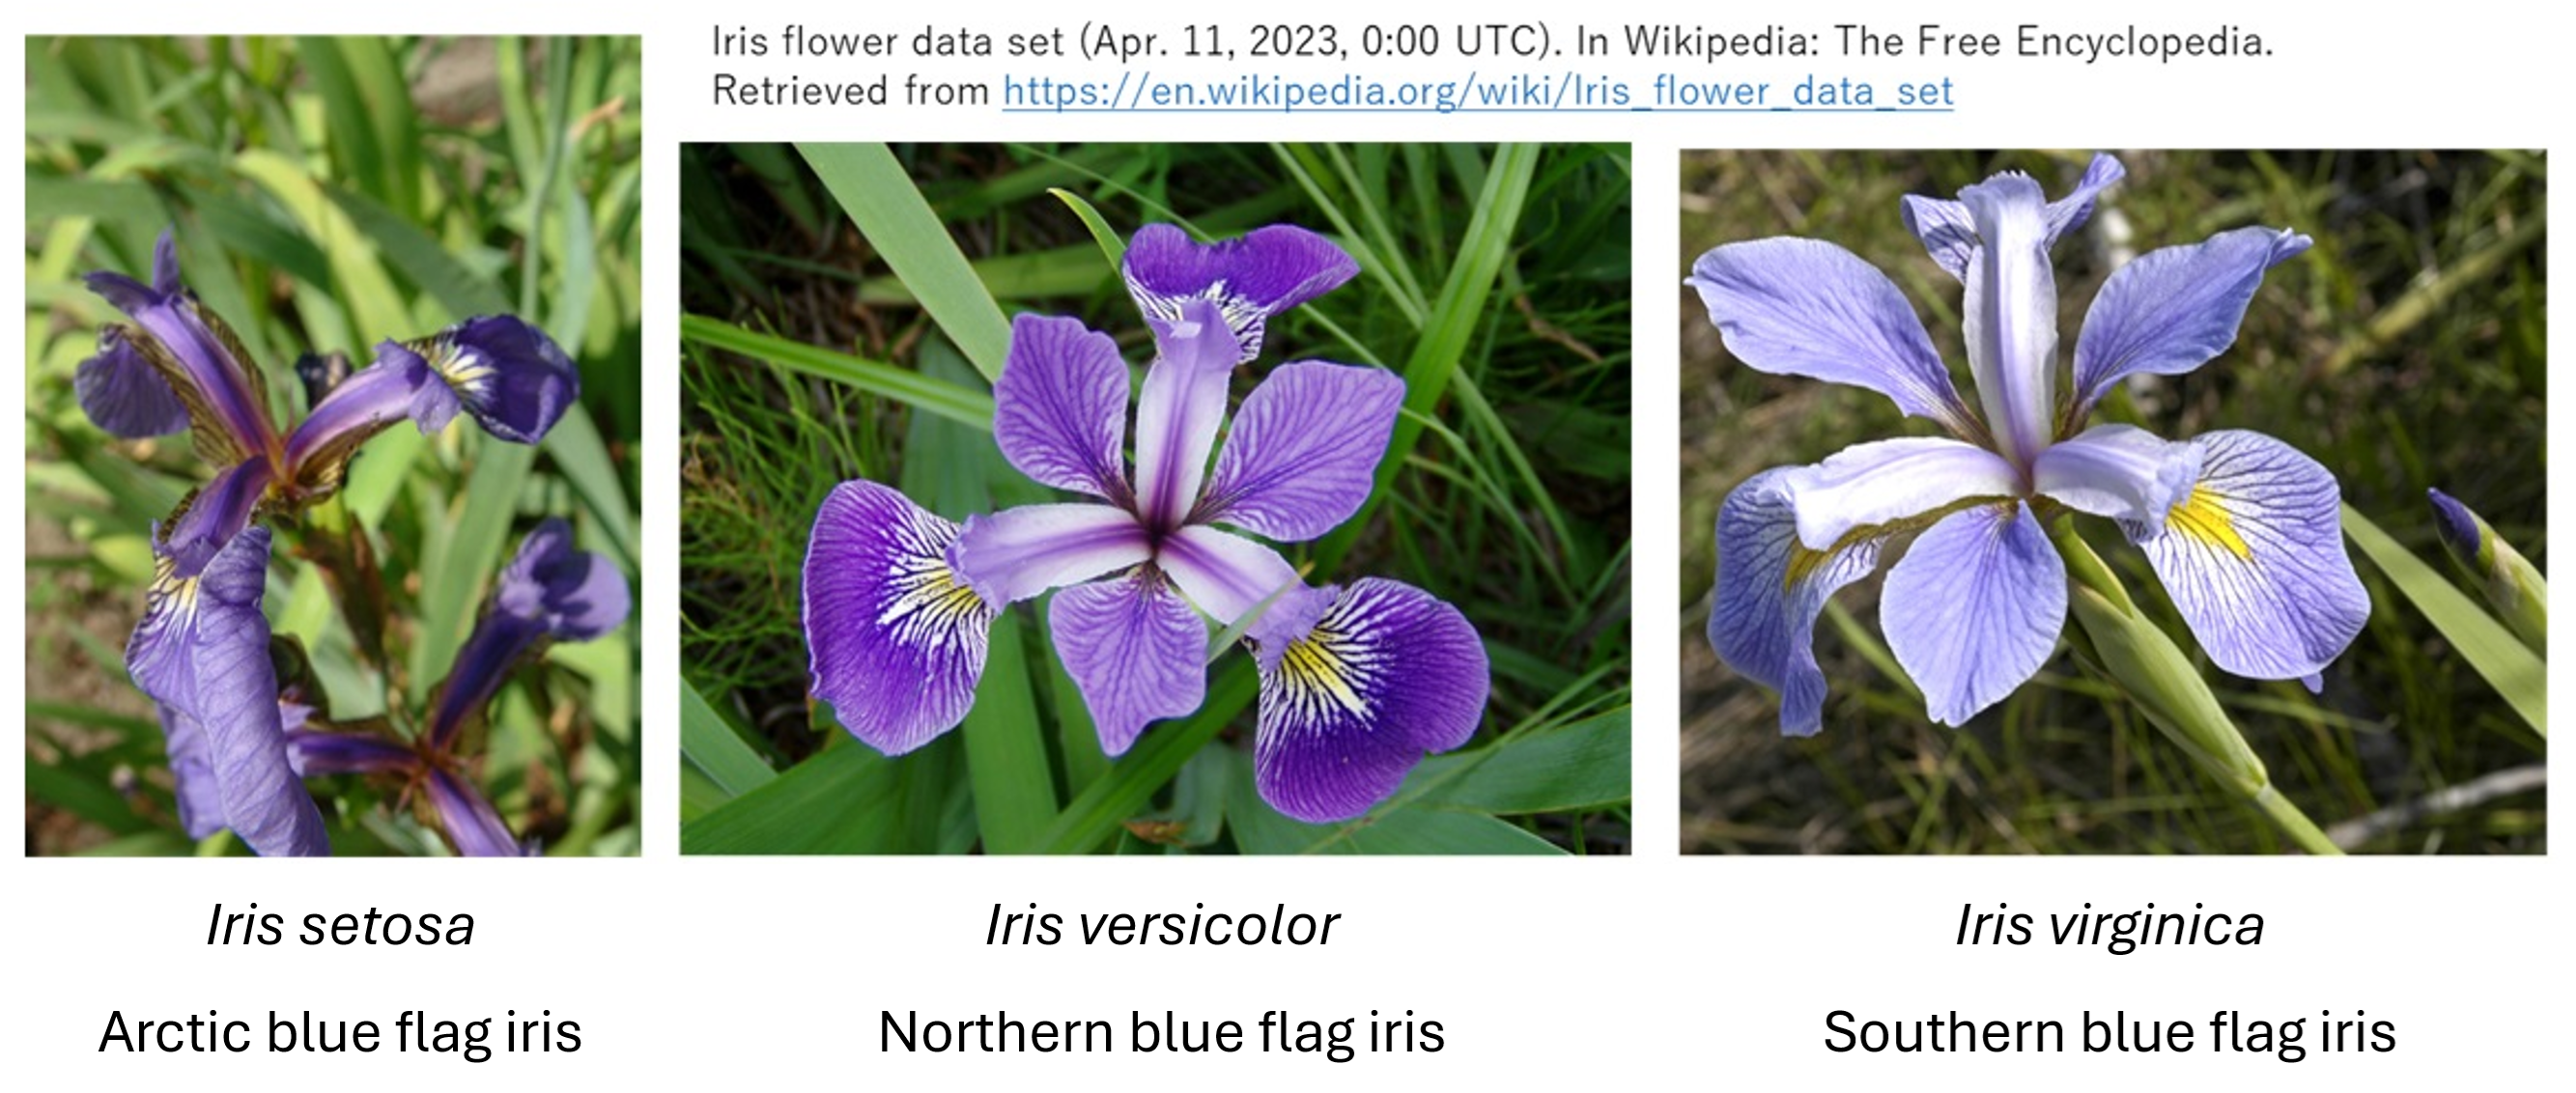

## Library Setup

Install external libraries that are not pre-installed in Colab.

In [7]:
import sklearn
import os


# Install libraries that are not pre-installed in Colab

!pip install -q dtreeviz==2.2.2 # Library for cleanly visualizing decision tree classification models

print('scikit-learn version:',sklearn.__version__)

restart_flag = False


if sklearn.__version__ != '1.6.1':
    !pip install -q --upgrade scikit-learn==1.6.1
    print('scikit-learn version:',sklearn.__version__)
    restart_flag = True

# The following is executed only if a library version was changed.
if restart_flag :
    print("If a library version was changed, the runtime will be restarted automatically.")
    print("In Colab, a warning saying [Your session crashed for an unknown reason] may appear at the bottom-left,")
    print("but it is safe to ignore this and proceed to execute the next code cells.")
    # Intentionally trigger a crash to restart the runtime.
    get_ipython().kernel.do_shutdown(restart=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.6 MB/s eta 0:00:00
scikit-learn version: 1.6.1


Import the libraries.

In [8]:
from IPython.display import display # Function that displays some data more cleanly than print() in environments like Colab
import numpy as np # numpy: a library for numerical computation
import pandas as pd # pandas: a library for tabular data
import matplotlib.pyplot as plt # matplotlib: a library for plotting graphs
plt.set_loglevel("error") # Suppress warnings

import seaborn as sns # seaborn: a library for plotting graphs
import dtreeviz # dtreeviz: a library for cleanly visualizing decision tree classification models

# scikit_learn: a library for machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import  classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
from sklearn.model_selection import LearningCurveDisplay

In [9]:
print('Default maximum number of rows to display:', pd.get_option('display.max_rows'))

# Set the maximum number of rows to display without truncation in table format
pd.set_option('display.max_rows', 150)

print('Updated maximum number of rows to display:', pd.get_option('display.max_rows'))

Default maximum number of rows to display: 60
Updated maximum number of rows to display: 150


## Data Exploration

In [10]:
# Load the iris dataset
iris = sns.load_dataset('iris')

print(iris.info())
# Display the first 10 rows
display(iris.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [11]:
# Rename columns to more readable English labels
iris.columns = ['Sepal Length','Sepal Width','Petal Length','Petal Width','Species']

In [12]:
print(iris.info())
# Display all rows
display(iris)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal Length  150 non-null    float64
 1   Sepal Width   150 non-null    float64
 2   Petal Length  150 non-null    float64
 3   Petal Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### Display Summary Statistics

In [13]:
# Display summary statistics
display(iris.describe())

,Sepal Length,Sepal Width,Petal Length,Petal Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Pair Plot

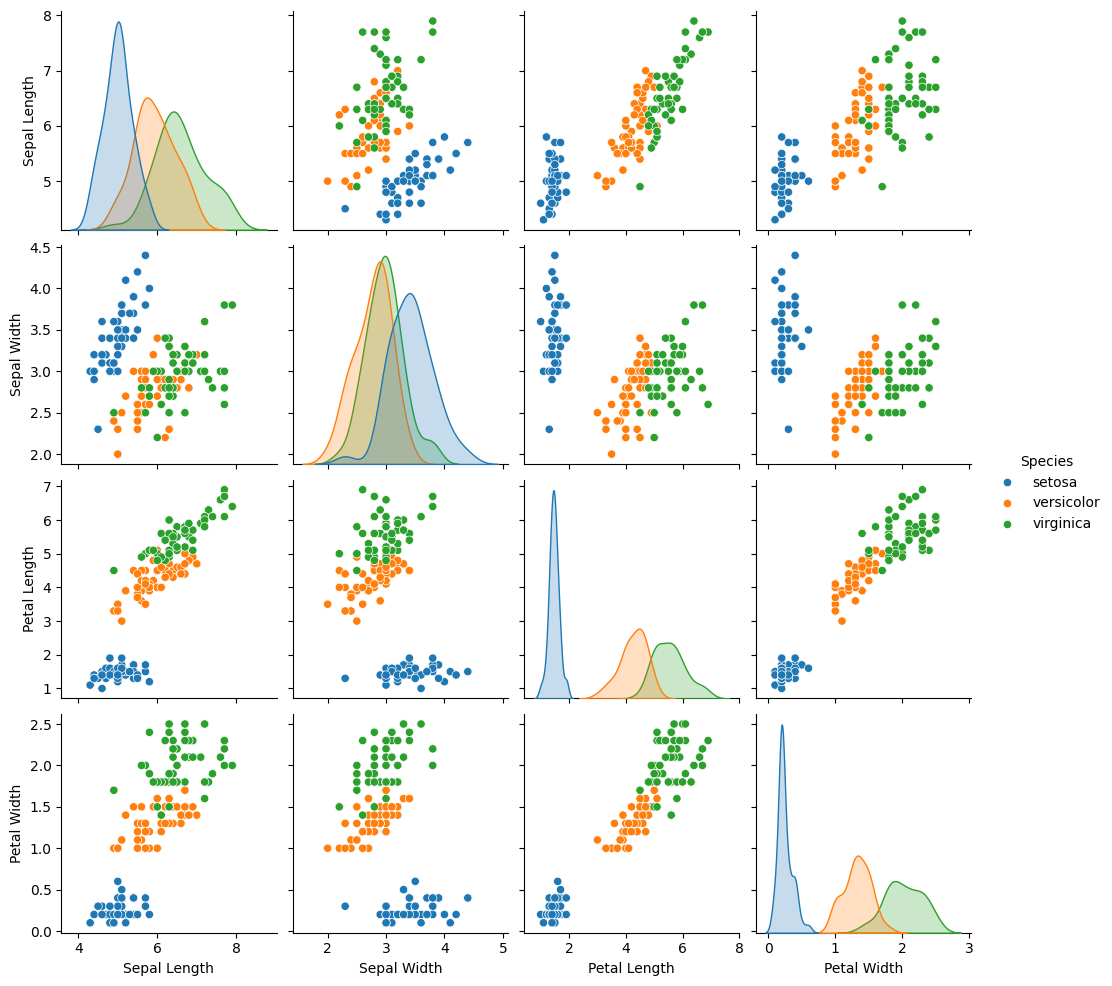

In [14]:
# Draw the scatter plot matrix of the iris dataset.
# Create a pair plot where the scatter plots of each pair of columns are arranged in a matrix.
# On the diagonal, a density distribution or histogram is drawn.
sns.pairplot(iris, hue='Species')
plt.show()

We can see that *setosa* appears to be linearly separable from the other two species.<br>
This is especially clear for petal length and petal width: at roughly petal length = 2.3 and petal width = 0.8, *setosa* can be separated from the other two species.<br>
On the other hand, the other two species have overlapping points, so it appears difficult to separate them with a simple straight-line boundary.<br>

In [15]:
# If petal length is less than 2.3, the species is setosa
display( iris[ iris['Petal Length'] < 2.3 ] )

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### Pie Chart

Let's check the proportion of data points for each species.<br>
This dataset has the same number of data points for each species, so we can see that it is a balanced dataset.

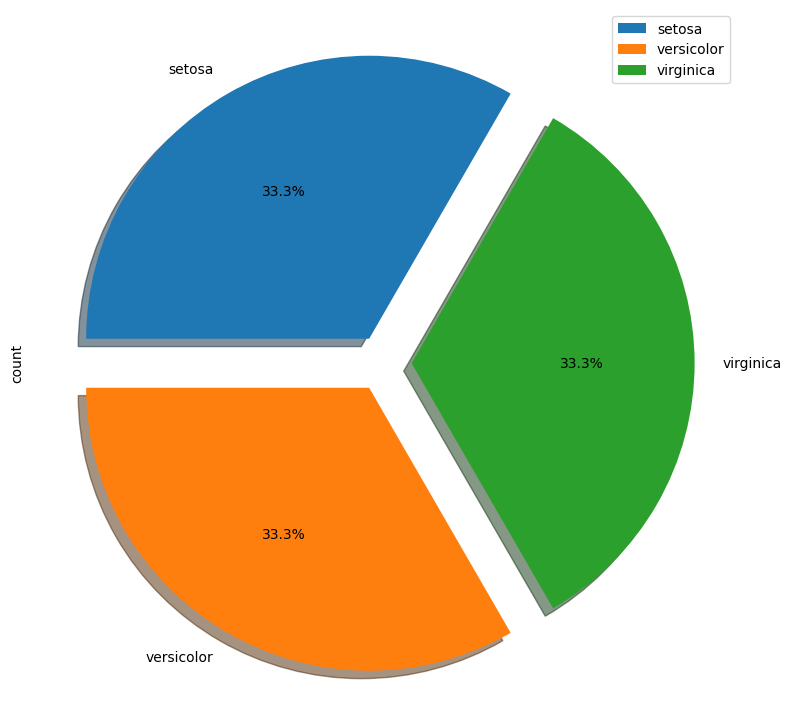

In [16]:
iris['Species'].value_counts().plot.pie(explode=[0.1,0.1,0.1],autopct='%1.1f%%',shadow=True, figsize=(8,8), startangle=60)
plt.legend()
plt.tight_layout()
plt.show()

## Scikit-learn (Decision Tree Classification)

There are many types and families of algorithms used in machine learning.

This time, we will use an algorithm belonging to one of them, the family called the "**Decision Tree**".

A decision tree is an algorithm inspired by a data structure called a **tree structure**, illustrated below.

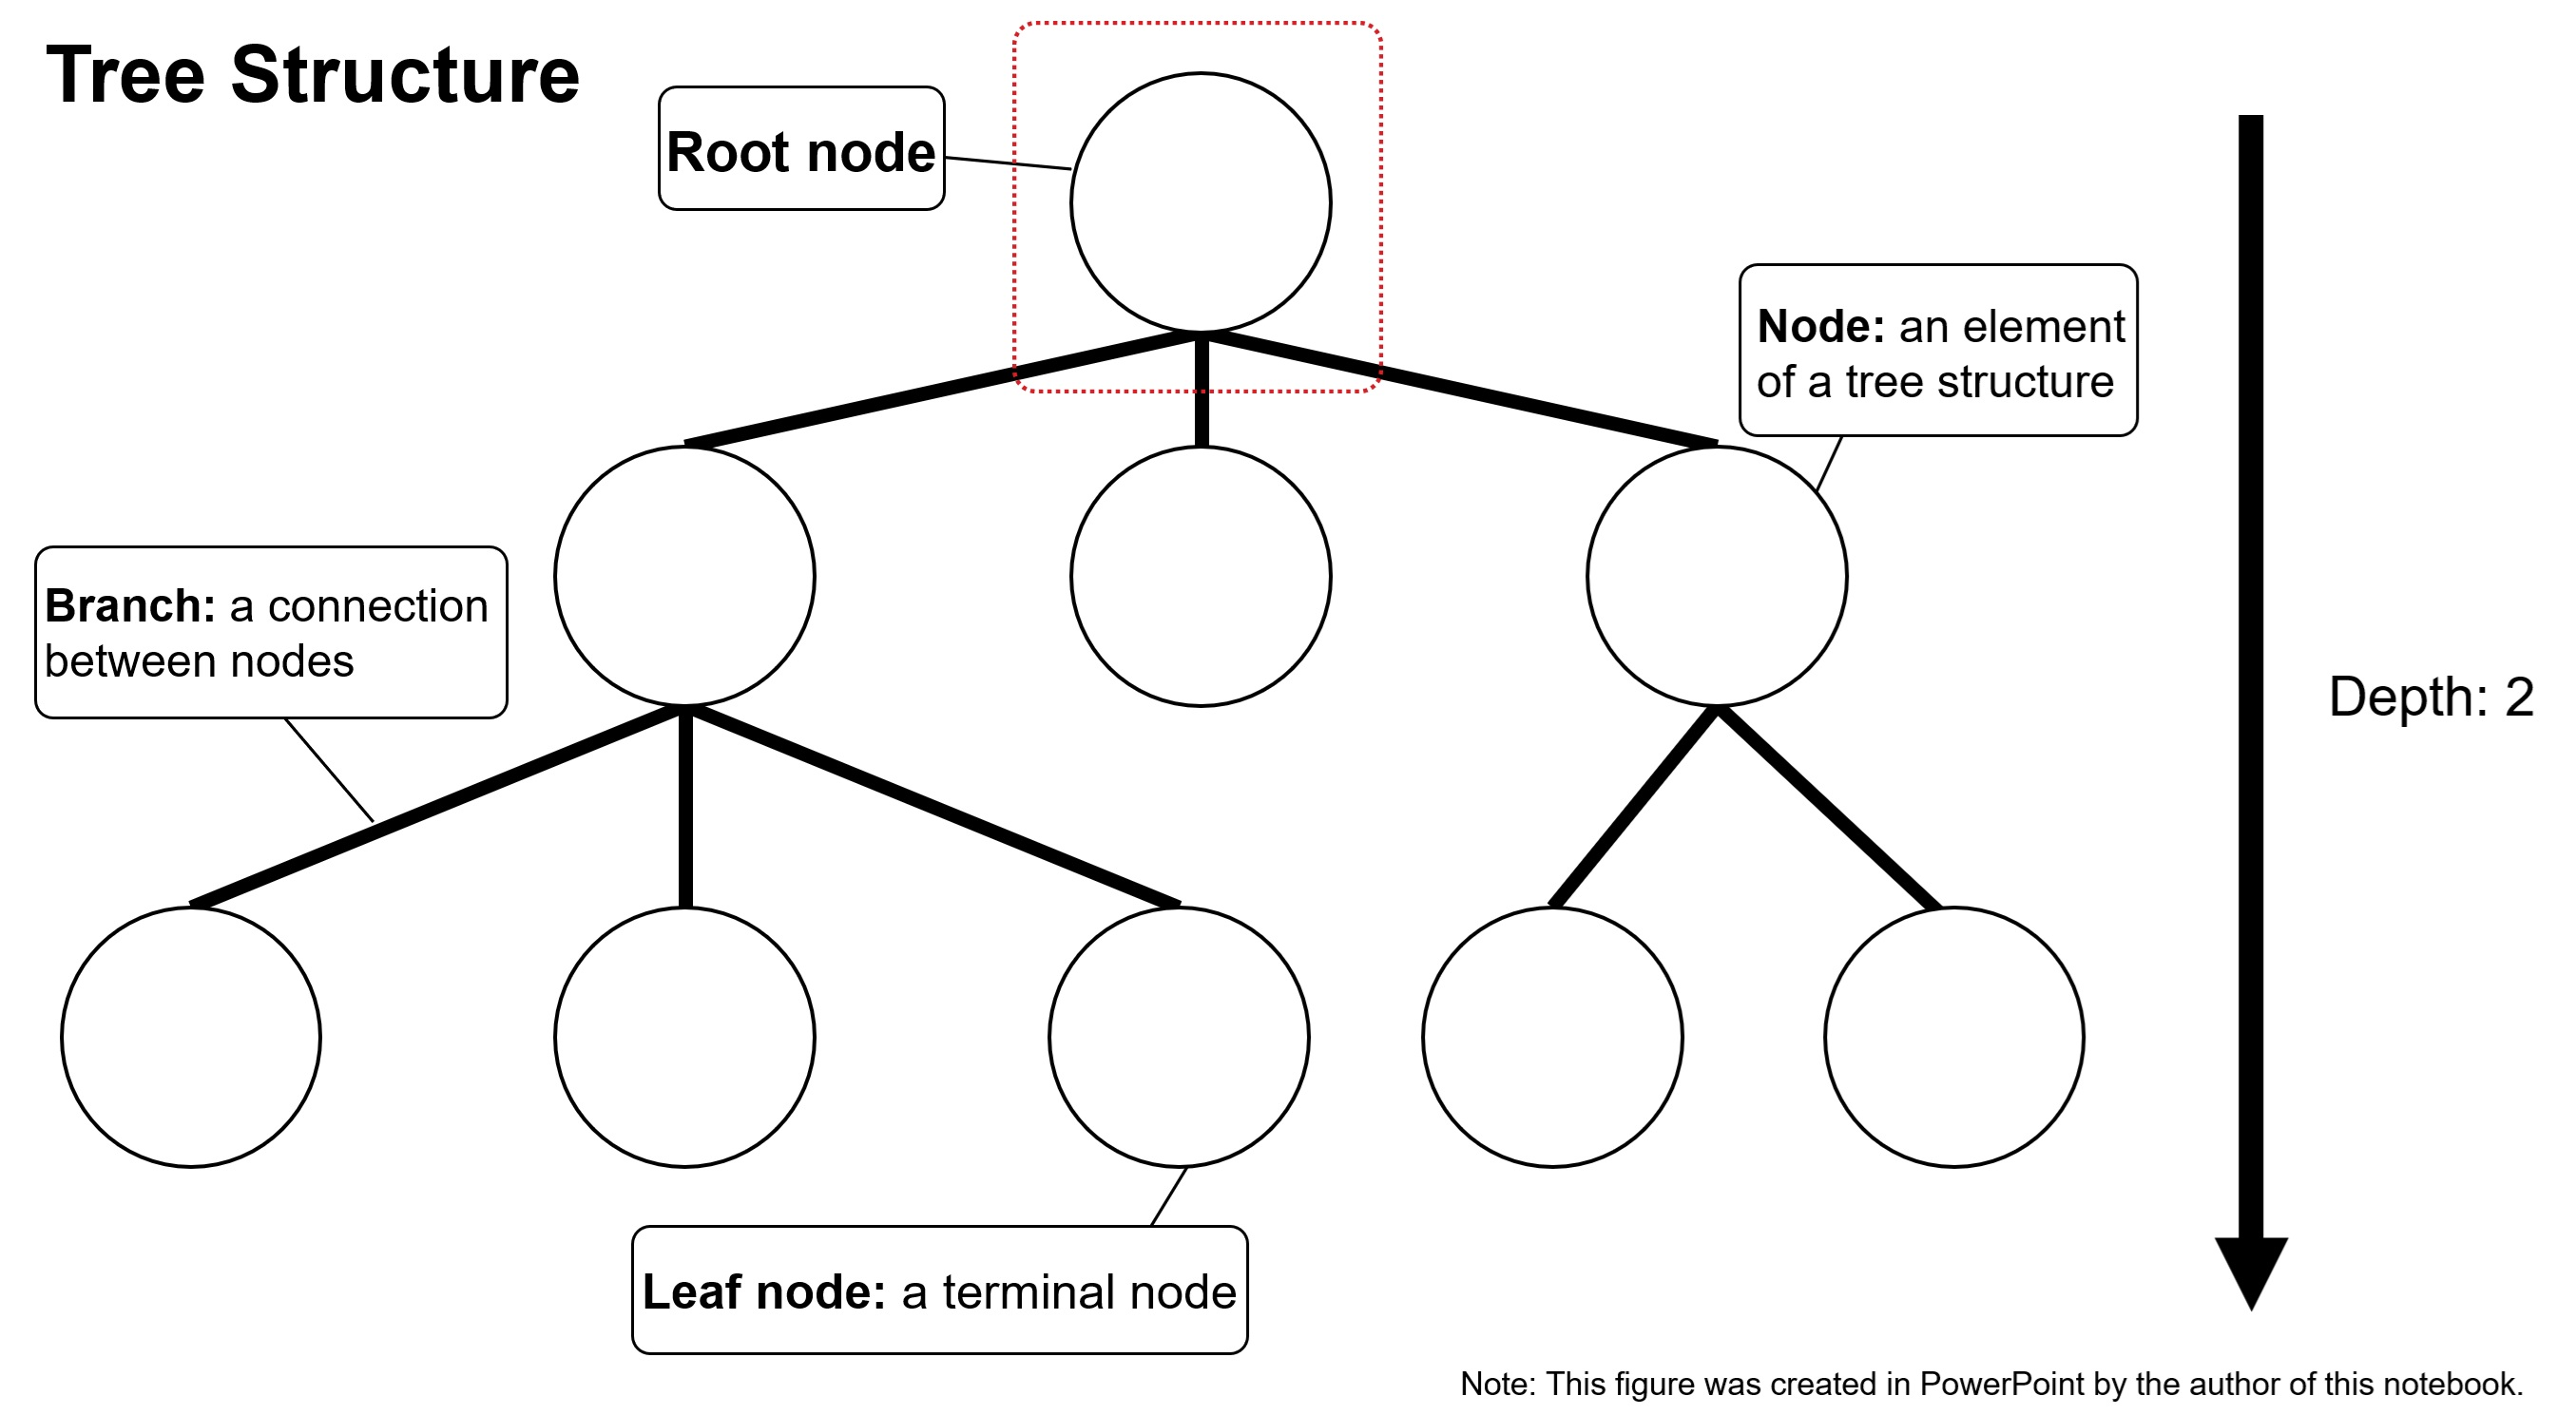



The advantages of decision tree algorithms are as follows:

1.   It is easy to interpret how classifications were made (the internals of the model can be visualized).
2.   Both explanatory variables and target variables can be handled regardless of the measurement scale.
>* Measurement scales: nominal, ordinal, interval, ratio
3.   Relatively robust to outliers.

Conversely, the disadvantages are as follows:

1.   Performance is not particularly high.
>* These days there are algorithms with better performance. However, higher-performing algorithms often have lower interpretability.
2.   Prone to overfitting.
>*   Hyperparameter tuning is required to prevent overfitting.
>*   A typical adjustment to prevent overfitting in a decision tree is to limit the depth of the tree (commonly called "pruning").
3.   Not particularly well suited for data with a linear relationship between explanatory and target variables.
>*   A decision tree is a non-linear model. It is not that it cannot represent linear data, but it tends to overfit.
4.  Connections between nodes are AND only.
5.  ...

etc.


### Encoding Nominal Variables as Numbers (Label Encoding)

The species of the flower is categorical data on a nominal scale. To use it in data analysis and machine learning algorithms, we convert these strings to numerical values.

>※ With the current version of the scikit-learn decision tree classification model, the model works even without encoding nominal variables as numbers. However, some external libraries do not work without numerical encoding, so for practice we perform label encoding here.

>※ When encoding nominal variables as numbers, some machine learning model algorithms require a preprocessing step called One-hot encoding. However, this is exceptionally not needed for the decision tree classification model, so we will not explain it here.

In [17]:
# The 'Species' column contains strings
display(iris.head(5))
display(iris['Species'].values)

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [18]:
from sklearn.preprocessing import LabelEncoder

# Preparation for performing label encoding
le = LabelEncoder()
# Perform label encoding on the 'Species' column and store the result in iris_label_encoded
iris_label_encoded = le.fit_transform(iris['Species'].values)
# Display iris_label_encoded
display( iris_label_encoded )

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Split into Training Data and Test Data

In [19]:
# X : input data
X = iris[ ['Sepal Length','Sepal Width','Petal Length','Petal Width'] ].values
# Y: output data (after label encoding)
Y = le.fit_transform(iris['Species'].values)

# train : training data
# test  : test data
# Split randomly
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=333)

In [20]:
# Inspect the contents of X_train
print(X_train)

[[6.3 2.9 5.6 1.8]
 [5.6 2.5 3.9 1.1]
 [5.1 3.5 1.4 0.3]
 [6.5 3.  5.2 2. ]
 [6.6 3.  4.4 1.4]
 [5.8 2.8 5.1 2.4]
 [4.6 3.6 1.  0.2]
 [6.7 2.5 5.8 1.8]
 [7.9 3.8 6.4 2. ]
 [4.4 3.2 1.3 0.2]
 [6.3 2.8 5.1 1.5]
 [4.8 3.1 1.6 0.2]
 [5.9 3.  4.2 1.5]
 [7.7 2.8 6.7 2. ]
 [4.4 2.9 1.4 0.2]
 [5.8 4.  1.2 0.2]
 [5.8 2.7 3.9 1.2]
 [5.3 3.7 1.5 0.2]
 [6.6 2.9 4.6 1.3]
 [5.1 3.4 1.5 0.2]
 [6.2 2.2 4.5 1.5]
 [5.4 3.9 1.3 0.4]
 [6.1 2.8 4.7 1.2]
 [5.6 2.8 4.9 2. ]
 [6.4 3.2 5.3 2.3]
 [7.4 2.8 6.1 1.9]
 [5.1 3.8 1.9 0.4]
 [5.  3.6 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  2.3 3.3 1. ]
 [7.7 3.8 6.7 2.2]
 [7.1 3.  5.9 2.1]
 [6.9 3.1 5.1 2.3]
 [4.8 3.4 1.6 0.2]
 [4.9 3.1 1.5 0.1]
 [6.5 3.  5.8 2.2]
 [5.5 2.4 3.8 1.1]
 [4.9 3.  1.4 0.2]
 [6.8 2.8 4.8 1.4]
 [4.8 3.  1.4 0.3]
 [5.  3.3 1.4 0.2]
 [6.9 3.1 4.9 1.5]
 [6.8 3.2 5.9 2.3]
 [5.  2.  3.5 1. ]
 [6.7 3.1 4.7 1.5]
 [5.  3.  1.6 0.2]
 [5.7 2.8 4.1 1.3]
 [5.4 3.  4.5 1.5]
 [5.4 3.7 1.5 0.2]
 [5.7 2.5 5.  2. ]
 [6.1 2.6 5.6 1.4]
 [5.1 3.5 1.4 0.2]
 [5.2 2.7 3.

In [21]:
# Inspect the contents of Y_train
print(Y_train)

[2 1 0 2 1 2 0 2 2 0 2 0 1 2 0 0 1 0 1 0 1 0 1 2 2 2 0 0 0 1 2 2 2 0 0 2 1
 0 1 0 0 1 2 1 1 0 1 1 0 2 2 0 1 1 1 2 0 2 0 1 1 1 2 2 0 1 0 0 1 0 0 2 1 0
 1 0 2 2 1 1 2 0 1 1 1 2 2 1 2 0 2 2 2 2 0 1 2 0 1 1 0 0 2 2 0]


### Building and Training the Decision Tree Classification Model
We build the decision tree classification model.
Parameters that humans adjust when building the model, such as those shown below, are called **hyperparameters**. In machine learning, the performance of the resulting model can change depending on how hyperparameters are tuned.

In [22]:
# Build the decision tree classification model
DT = tree.DecisionTreeClassifier(
    criterion = 'gini', # one of 'gini', 'entropy', 'log_loss'
    splitter = 'best', # 'best' or 'random'
    max_depth = None, # positive integer; maximum depth of the splits
    min_samples_split = 2, # positive integer recommended, 0 < min_samples_split < n_samples; setting too large here lowers accuracy.
    min_samples_leaf = 1, # positive integer recommended, 0 < min_samples_leaf < n_samples; setting too large here lowers accuracy.
    min_weight_fraction_leaf = 0.0,  # Do not change this for this exercise.
    max_features = None, # For this exercise, select one of None, 'sqrt', 'log2' (None is most appropriate here).
    random_state = 42, # positive integer; seed for the pseudo-random number generator
    max_leaf_nodes = None, # positive integer; maximum number of leaf nodes
    min_impurity_decrease = 0.0, # Do not change this for this exercise.
    class_weight = None, # Do not change this for this exercise.
    ccp_alpha = 0.0 # Do not change this for this exercise.
)

# Train the decision tree classification model on the training data
DT = DT.fit(X = X_train, # explanatory variables of the training data
            y = Y_train, # target variable of the training data
            sample_weight=None, # Do not change this for this exercise.
            check_input=True # Do not change this for this exercise.
            )

The argument descriptions are provided below.<br>
For more detailed explanations, refer to the [scikit-learn documentation page](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

Argument description for `tree.DecisionTreeClassifier()`:

|Argument|Optional/Required|Input value|Notes|
|----|----|----|----|
|criterion| Optional |'gini', 'entropy','log_loss'　Default: 'gini'|The function used to numerically express the quality of a split. The available criteria are 'gini' for Gini impurity, and 'log_loss' or 'entropy' for Shannon information gain.|
|splitter| Optional |'best', 'random'　Default: 'best'| The strategy used to choose the split at each node. The available strategies are ```'best'``` to choose the best split and ```'random'``` to choose the best random split.|
|max_depth |Optional|int, default: None|The maximum depth of the tree. If ```None```, nodes are expanded until all leaves are pure or until all leaves contain fewer than ```min_samples_split``` samples.|
|min_samples_split|Optional| int or float, default: 2|If ```min_samples_split``` is an int, the value is considered the minimum number of samples required to split an internal node.<br>If ```min_samples_split``` is a float, it is treated as ```ceil(min_samples_split * n_samples)```, so the minimum number varies with the sample size.|
|min_samples_leaf| Optional| int or float, default: 1|The minimum number of samples required to be at a leaf node. A split point at any depth is considered only if it leaves at least ```min_samples_leaf``` training samples in each of the left and right branches. (For regression models, this has a smoothing effect.)<br>If ```min_samples_leaf``` is an int, the value is considered the minimum number.<br>If a float, it is treated as ```ceil(min_samples_leaf * n_samples)```, so the minimum varies with the sample size.|
|min_weight_fraction_leaf|Optional| float, default: 0.0|**Do not change this for this exercise. (We do not use sample weights.)**|
|max_features |Optional| int, float, 'sqrt', or 'log2', default: None|The number of features to consider when looking for the best split.<br>If int, ```max_features``` features are considered at each split.<br>If float, it is treated as ```max(1, int(max_features * n_features_in_))```, so it varies with the number of features.<br>If ```'sqrt'```, ```max_features=sqrt(n_features)```.<br>If ```'log2'```, ```max_features=log2(n_features)```.<br>If ```None```, ```max_features=n_features```.<br>Note: Even if a valid partition of the node samples requires effectively inspecting more than ```max_features``` features, the search for a split does not stop until at least one valid partition of the node samples is found.|
|random_state|Optional| int, RandomState instance, or None, default: None|Controls the randomness of the decision tree model.<br>If None, the features are always randomly permuted at each split, even if ```splitter``` is set to ```'best'```. So when ```max_features <= n_features```, the "best found split" may vary across different runs.<br>To obtain deterministic behavior during training (the same results every time), ```random_state``` has to be fixed to an integer.|
|max_leaf_nodes|Optional| int, default: None|Grow a tree with at most ```max_leaf_nodes``` leaf nodes in a best-first fashion. Best nodes are defined as the relative reduction in impurity. If None, there is no limit on the number of leaf nodes.|
|min_impurity_decrease |Optional| float, default: 0.0|A node will be split if this split induces a decrease of the impurity greater than or equal to this value.|
|class_weight|Optional| dict, list of dicts, or 'balanced', default: None|**Do not change this for this exercise. (We do not use sample weights.)**|
|ccp_alpha|Optional| non-negative float, default: 0.0|Complexity parameter used for Minimal Cost-Complexity Pruning. **Do not change this for this exercise.**|

### Inference with the Trained Decision Tree Classification Model

In [23]:
# Run inference on the test data with the trained decision tree classification model
prediction = DT.predict(X_test)

print('Inference results on the test data (numeric labels):', prediction)

# Reverse the label encoding
print('Inference results on the test data:', le.inverse_transform(prediction))

Inference results on the test data (numeric labels): [0 2 0 0 0 2 0 1 1 2 2 1 0 2 2 1 0 0 2 2 2 0 1 1 2 2 0 0 1 1 1 0 1 2 2 0 2
 1 2 0 1 1 1 1 2]
Inference results on the test data: ['setosa' 'virginica' 'setosa' 'setosa' 'setosa' 'virginica' 'setosa'
 'versicolor' 'versicolor' 'virginica' 'virginica' 'versicolor' 'setosa'
 'virginica' 'virginica' 'versicolor' 'setosa' 'setosa' 'virginica'
 'virginica' 'virginica' 'setosa' 'versicolor' 'versicolor' 'virginica'
 'virginica' 'setosa' 'setosa' 'versicolor' 'versicolor' 'versicolor'
 'setosa' 'versicolor' 'virginica' 'virginica' 'setosa' 'virginica'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'virginica']


In [24]:
# Compare the correct labels of the test data against the inference results
print( classification_report( y_true = Y_test, y_pred = prediction, target_names = iris['Species'].unique() ) )

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.93      0.88      0.90        16
   virginica       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.94      0.94      0.94        45
weighted avg       0.93      0.93      0.93        45



In [25]:
# Compute the Accuracy score
from sklearn import metrics
print('Accuracy Score:', metrics.accuracy_score( Y_test, prediction))

Accuracy Score: 0.9333333333333333


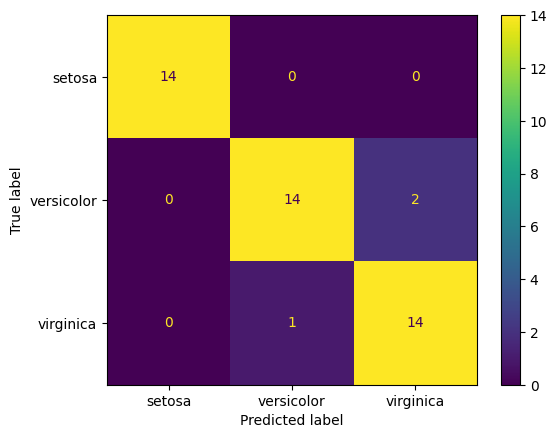

In [26]:
# Draw the confusion matrix
cm = confusion_matrix(Y_test, prediction, labels=DT.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=iris['Species'].unique())
disp.plot()
plt.show()

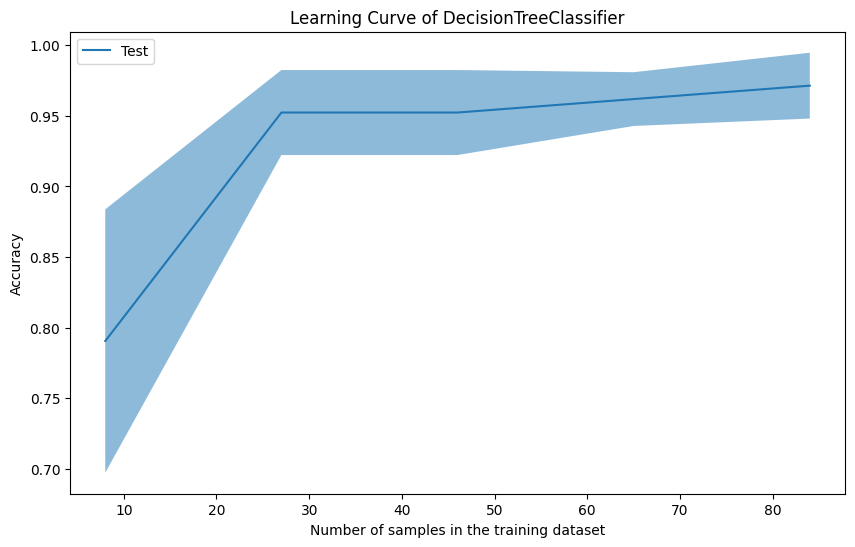

In [27]:
# Draw the learning curve

from sklearn.model_selection import LearningCurveDisplay

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
_ = LearningCurveDisplay.from_estimator(estimator=DT, X=X_train, y=Y_train, \
                                    score_type='test', \
                                    scoring='accuracy', score_name='Accuracy', \
                                    ax=ax)
ax.legend()
ax.set_title(f"Learning Curve of {DT.__class__.__name__}")
ax.set_xlabel('Number of samples in the training dataset')
plt.show()

In machine learning, generally speaking, with a sufficient quantity and quality of training data, it tends to be easier to improve accuracy.

However, there is a limit. In this iris dataset example, blindly increasing the size of the dataset further is unlikely to improve accuracy much beyond a certain point.

>※ The iris dataset is often cited as an extremely simple problem in machine learning.

### Visualizing the Decision Tree Classification Model

#### Text-based Output

In [28]:
# Output as a text file
text_representation = tree.export_text(decision_tree=DT, feature_names= ['Sepal Length','Sepal Width','Petal Length','Petal Width'] )

with open("./iris_DecisionTree_text.txt", "w") as file:
    file.write(text_representation)

print(text_representation)

|--- Petal Length <= 2.60
|   |--- class: 0
|--- Petal Length >  2.60
|   |--- Petal Width <= 1.65
|   |   |--- Petal Length <= 5.00
|   |   |   |--- class: 1
|   |   |--- Petal Length >  5.00
|   |   |   |--- Sepal Length <= 6.05
|   |   |   |   |--- class: 1
|   |   |   |--- Sepal Length >  6.05
|   |   |   |   |--- class: 2
|   |--- Petal Width >  1.65
|   |   |--- class: 2



#### Output with dtreeviz

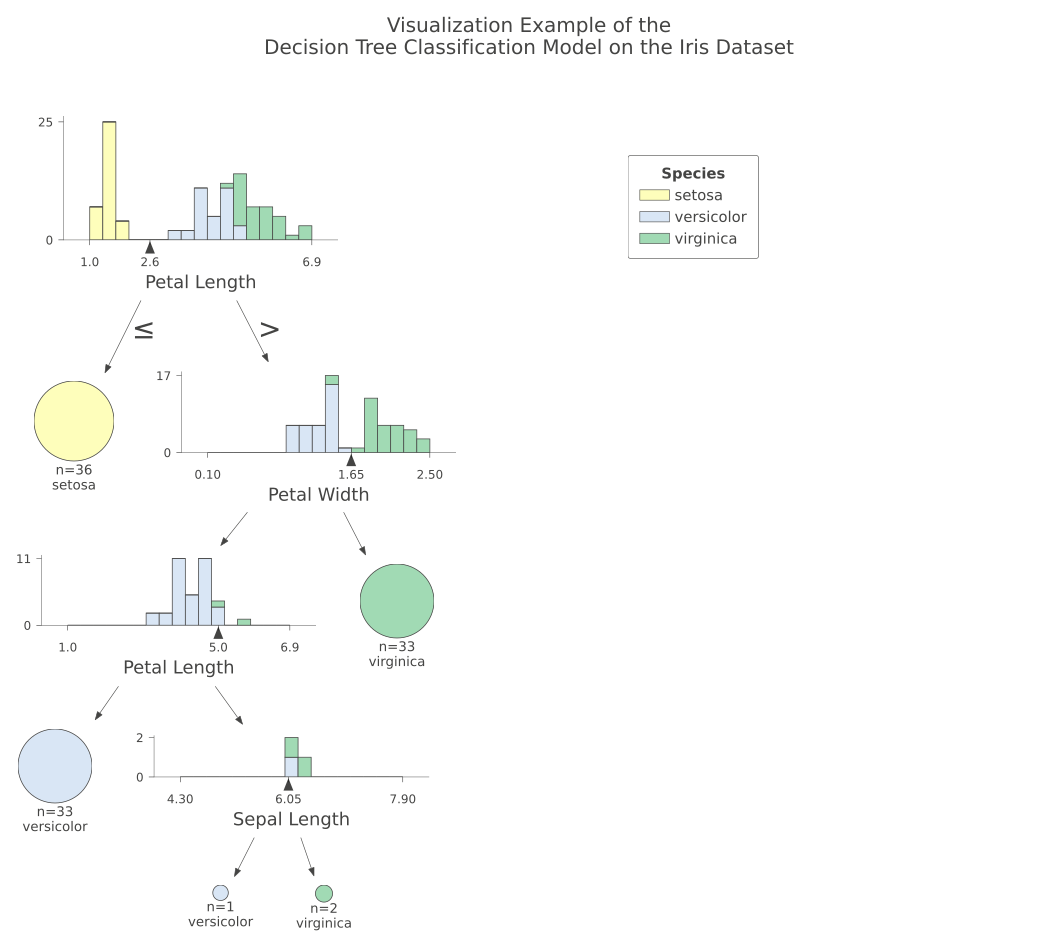

In [29]:
viz_model = dtreeviz.model(DT,
                           X_train=X_train,
                           y_train=Y_train,
                           feature_names=['Sepal Length','Sepal Width','Petal Length','Petal Width'],
                           target_name='Species',
                           class_names=iris['Species'].unique().tolist()
                           )

viz_model.view(fontname = 'DejaVu Sans', # Font specification
               title = 'Visualization Example of the\nDecision Tree Classification Model on the Iris Dataset', # Graph title
               scale = 2.0, # Overall text-size scale
               orientation = 'TD', # Tree orientation: 'TD' or 'LR'
               fancy = True, # Whether to visualize the decision boundary of features
               show_root_edge_labels = True, # Whether to display the value relation on the branches from root to nodes
               histtype = 'barstacked', # Histogram format: one of 'bar', 'barstacked', 'strip'
               leaftype = 'pie' # Leaf graph format: one of 'pie', 'barh'
               )

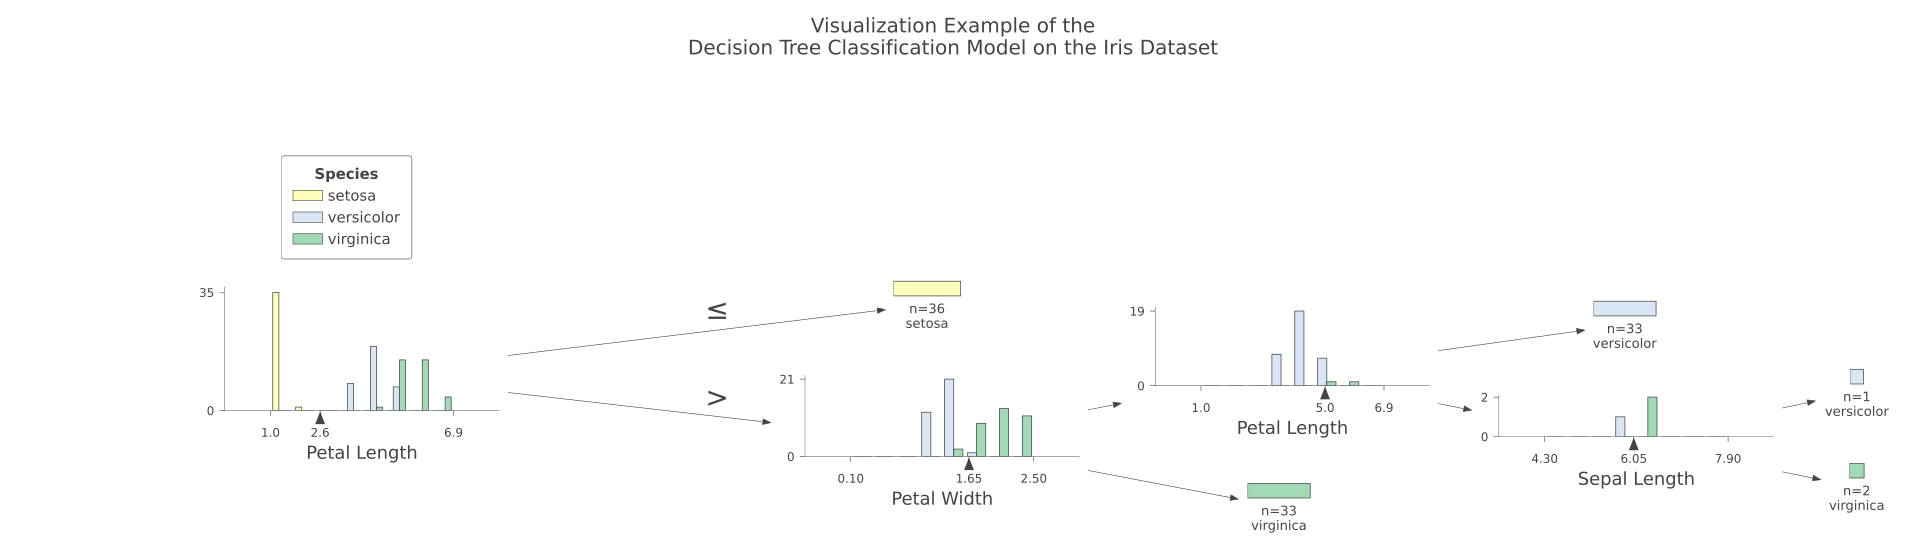

In [30]:
viz_model.view(fontname = 'DejaVu Sans', # Font specification
               title = 'Visualization Example of the\nDecision Tree Classification Model on the Iris Dataset', # Graph title
               scale = 2.0, # Overall text-size scale
               orientation = 'LR', # Tree orientation: 'TD' or 'LR'
               fancy = True, # Whether to visualize the decision boundary of features
               show_root_edge_labels = True, # Whether to display the value relation on the branches from root to nodes
               histtype = 'bar', # Histogram format: one of 'bar', 'barstacked', 'strip'
               leaftype = 'barh' # Leaf graph format: one of 'pie', 'barh'
               )

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
101,5.8,2.7,5.1,1.9,virginica


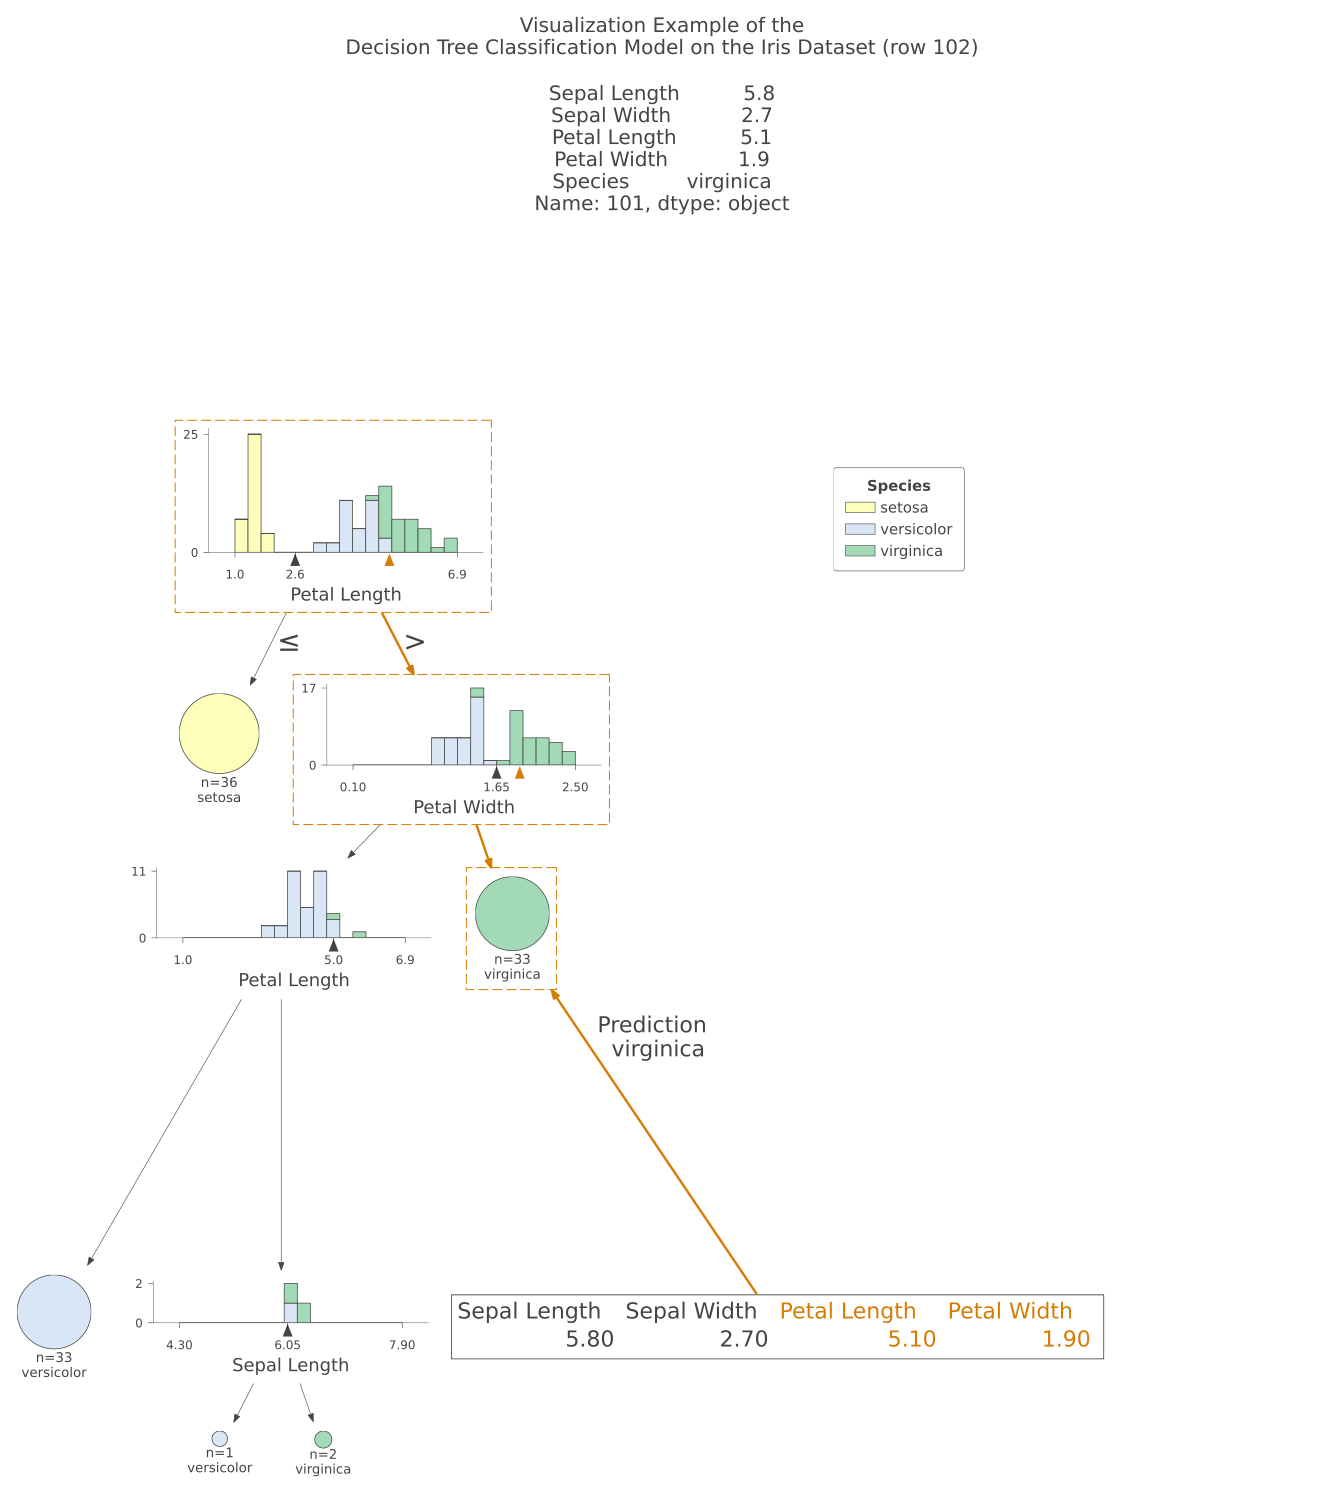

In [31]:
# Below is the 102nd row of the iris dataset.
# Python uses zero-based indexing, so the 102nd row is at index 101.
index = 101
display( iris.loc[index,['Sepal Length','Sepal Width','Petal Length','Petal Width','Species']].to_frame().T)

viz_model = dtreeviz.model(DT,
                           X_train=X_train,
                           y_train=Y_train,
                           feature_names=['Sepal Length','Sepal Width','Petal Length','Petal Width'],
                           target_name='Species', class_names=iris['Species'].unique().tolist())

viz_model.view(fontname = 'DejaVu Sans', # Font specification
               title = f'Visualization Example of the\nDecision Tree Classification Model on the Iris Dataset (row {index+1})\n\n{ iris.loc[index,:] }', # Graph title
               scale = 2.0, # Overall text-size scale
               orientation = 'TD', # Tree orientation: 'TD' or 'LR'
               fancy = True, # Whether to visualize the decision boundary of features
               show_root_edge_labels = True, # Whether to display the value relation on the branches from root to nodes
               histtype = 'barstacked', # Histogram format: one of 'bar', 'barstacked', 'strip'
               leaftype = 'pie', # Leaf graph format: one of 'pie', 'barh'
               # Specify a particular data point: the 102nd row of the iris dataset.
               x = iris.loc[index,['Sepal Length','Sepal Width','Petal Length','Petal Width']].reset_index(drop=True),
               )

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
70,5.9,3.2,4.8,1.8,versicolor


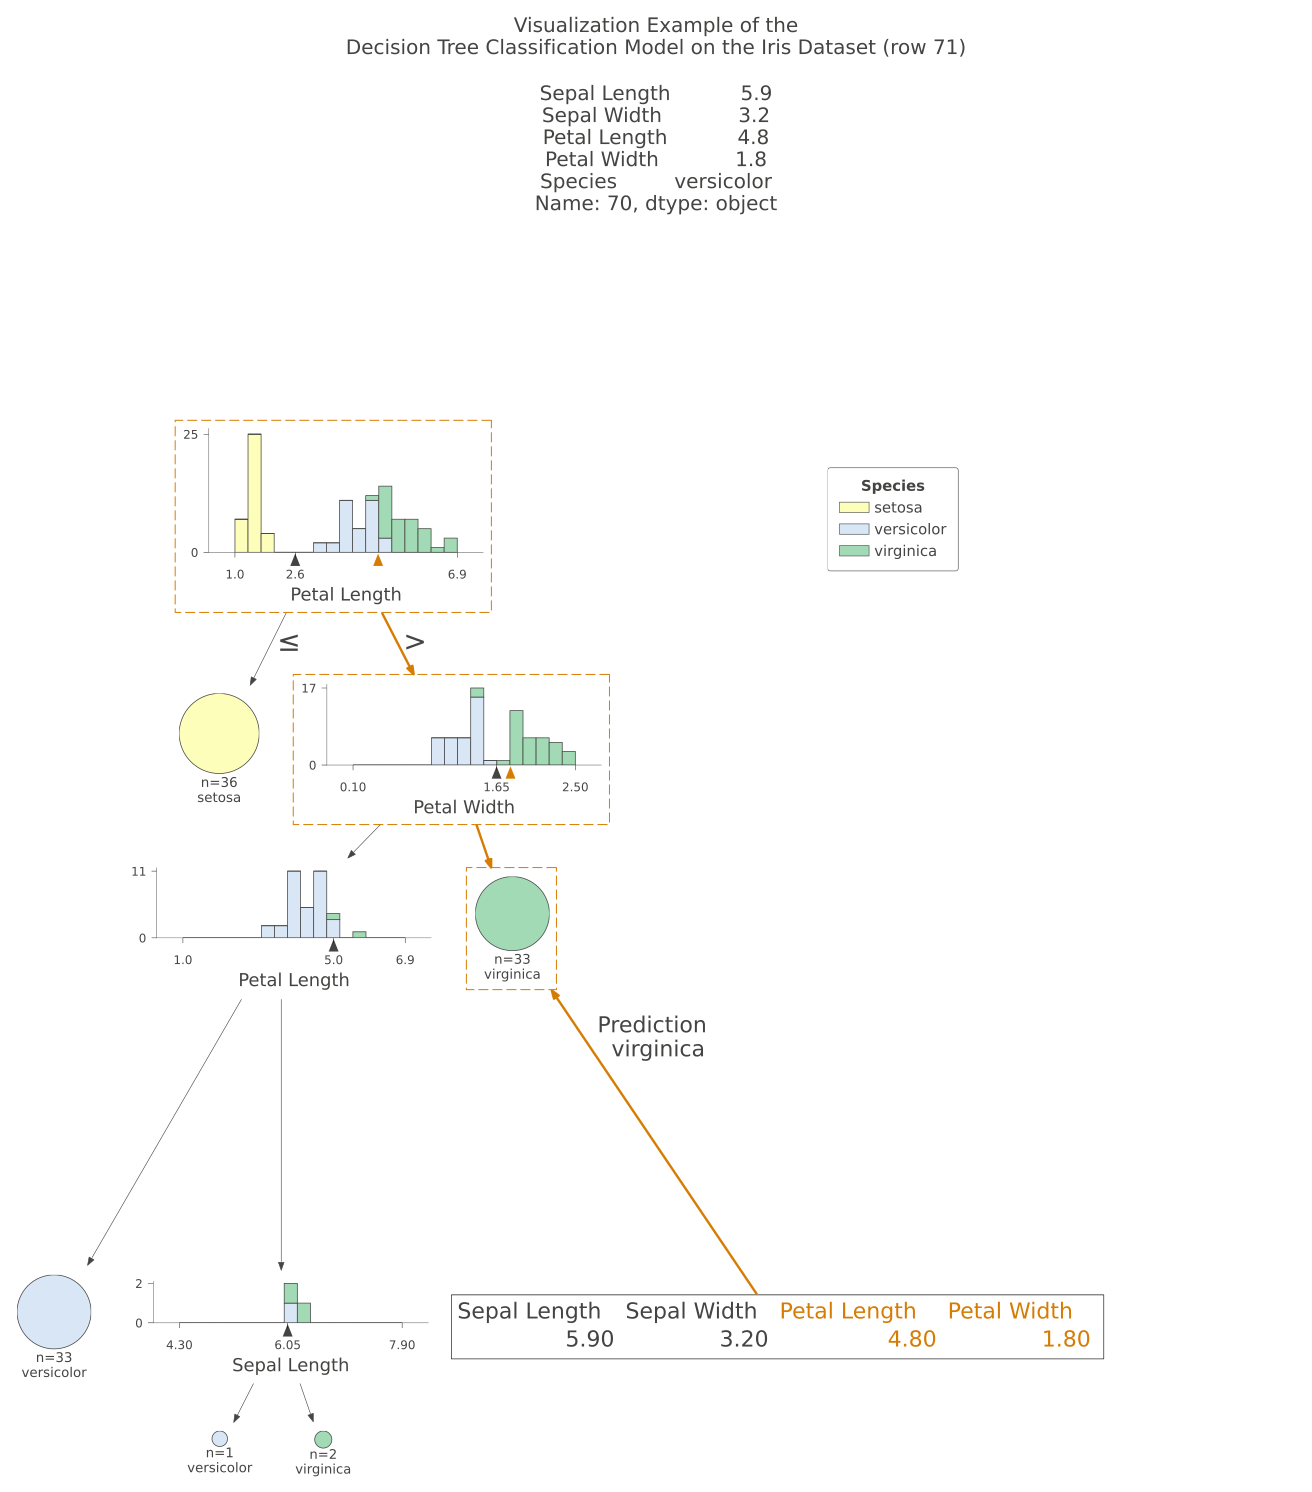

In [32]:
# Below is the 71st row of the iris dataset.
# Python uses zero-based indexing, so the 71st row is at index 70.
index = 70
display( iris.loc[index,['Sepal Length','Sepal Width','Petal Length','Petal Width','Species']].to_frame().T)

viz_model = dtreeviz.model(DT,
                           X_train=X_train,
                           y_train=Y_train,
                           feature_names=['Sepal Length','Sepal Width','Petal Length','Petal Width'],
                           target_name='Species', class_names=iris['Species'].unique().tolist())

viz_model.view(fontname = 'DejaVu Sans', # Font specification
               title = f'Visualization Example of the\nDecision Tree Classification Model on the Iris Dataset (row {index+1})\n\n{ iris.loc[index,:] }', # Graph title
               scale = 2.0, # Overall text-size scale
               orientation = 'TD', # Tree orientation: 'TD' or 'LR'
               fancy = True, # Whether to visualize the decision boundary of features
               show_root_edge_labels = True, # Whether to display the value relation on the branches from root to nodes
               histtype = 'barstacked', # Histogram format: one of 'bar', 'barstacked', 'strip'
               leaftype = 'pie', # Leaf graph format: one of 'pie', 'barh'
               # Specify a particular data point: the 71st row of the iris dataset.
               x = iris.loc[index,['Sepal Length','Sepal Width','Petal Length','Petal Width']].reset_index(drop=True)
               )

As shown here, by visualizing the internals of the decision tree classification model,
humans can understand **what criteria were used to perform the classification**.